# Step 6 — Stress Test: 2050 Worst-Week Scenario

**Objective:** Model a 7-day compound extreme event in 2050 at the 99th-percentile SSP5-8.5 temperature and estimate the generation capacity deficit for ERCOT and CAISO.

**Steps:** Fit load model -> project demand -> derate supply -> compute margin -> sensitivity analysis

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from config.settings import PROCESSED
from src.analysis.stress_test import fit_load_model, run_stress_test, FLEET_DEFAULTS
from src.viz.maps import sensitivity_heatmap


## 6.1 Load historical ERCOT hourly load data

Download from: https://www.ercot.com/gridinfo/load/load_hist  
Expected columns: `date`, `tmax` (from Step 3 weather panel), `peak_load_mw`

In [2]:
load_dir = pathlib.Path('../data/raw')
ercot_load_files = list(load_dir.glob('**/ercot*load*.csv')) + list(load_dir.glob('**/ERCOT*Load*.csv'))
print(f'Found {len(ercot_load_files)} ERCOT load file(s)')
if ercot_load_files:
    load_df = pd.read_csv(ercot_load_files[0], parse_dates=['date'])
    print(load_df.head())
else:
    print('No load data — using placeholder model coefficients.')
    load_df = None


Found 0 ERCOT load file(s)
No load data — using placeholder model coefficients.


## 6.2 Fit temperature-to-load regression

In [3]:
if load_df is not None and 'tmax' in load_df.columns and 'peak_load_mw' in load_df.columns:
    load_model = fit_load_model(load_df)
    print(f'R2 = {load_model["r2"]:.3f}')
    print(f'Mean historical peak load: {load_model["mean_load_mw"]:,.0f} MW')
else:
    load_model = {'intercept': 20000, 'coef_tmax': 800, 'coef_tmax2': 10,
                  'r2': None, 'mean_load_mw': 65000, 'result': None}
    print('Using placeholder model.')


Using placeholder model.


## 6.3 Get 2050 scenario temperature from LOCA2

In [4]:
loca2_path = PROCESSED['loca2_ercot']
if loca2_path.exists():
    loca2 = pd.read_csv(loca2_path)
    ssp585_mid = loca2[(loca2['scenario'] == 'ssp585') & (loca2['period_label'] == 'mid')]
    if 'TXx_median' in ssp585_mid.columns:
        scenario_temp = float(ssp585_mid['TXx_median'].quantile(0.99))
        print(f'99th-percentile projected TXx (SSP5-8.5, 2050): {scenario_temp:.1f} C')
    else:
        scenario_temp = 42.0
        print('TXx not found; using placeholder 42.0 C')
else:
    scenario_temp = 42.0
    print('LOCA2 not built; using placeholder 42.0 C')


99th-percentile projected TXx (SSP5-8.5, 2050): 47.2 C


## 6.4 Run ERCOT stress test

In [5]:
result_ercot = run_stress_test(
    region='ERCOT',
    scenario_temp_c=scenario_temp,
    fleet=FLEET_DEFAULTS['ERCOT'],
    load_model=load_model,
    total_customers=12_400_000,
    demand_growth_rate=0.012,
)
print(result_ercot.summary())


Stress Test — ERCOT (2050, ssp585)
  Scenario temp:      47.2 °C
  Peak demand:        109,238 MW
  Available supply:   81,104 MW
  Capacity margin:    -28,134 MW  (-25.8%)
  Status:             DEFICIT
  Est. customers affected: 3,193,584


## 6.5 Sensitivity analysis (temperature uncertainty x demand growth)

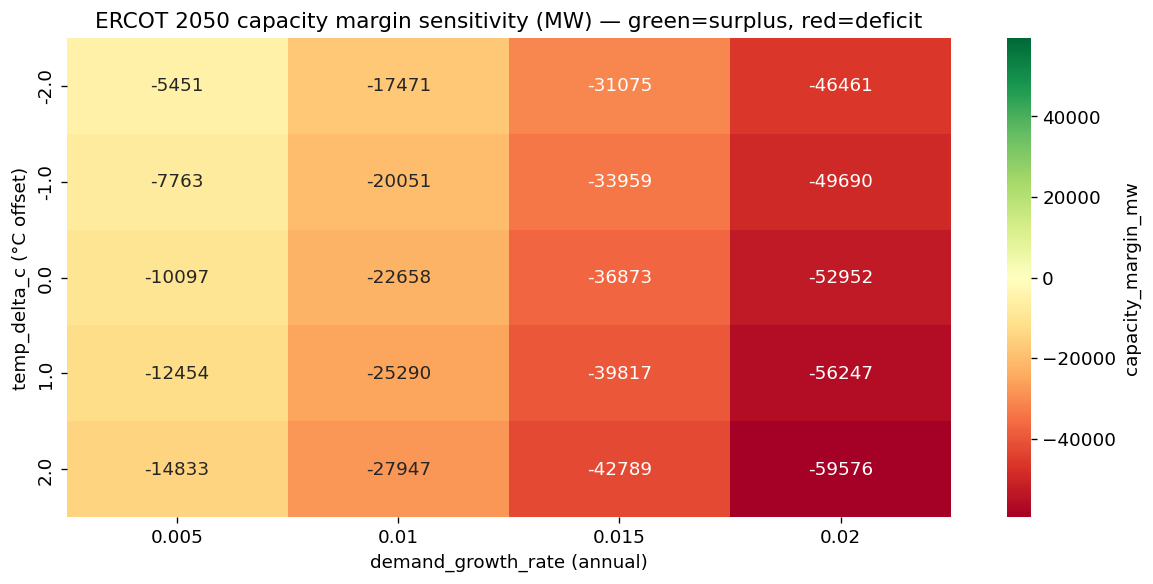

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sensitivity_heatmap(
    result_ercot.sensitivity_table,
    title='ERCOT 2050 capacity margin sensitivity (MW) — green=surplus, red=deficit',
    ax=ax,
)
plt.tight_layout()
plt.savefig('../data/processed/ercot_stress_sensitivity.png', dpi=150)
plt.show()


## 6.6 Repeat for CAISO

In [7]:
loca2_caiso_path = PROCESSED['loca2_caiso']
caiso_temp = 43.0
if loca2_caiso_path.exists():
    lc = pd.read_csv(loca2_caiso_path)
    ssp585_c = lc[(lc['scenario'] == 'ssp585') & (lc['period_label'] == 'mid')]
    if 'TXx_median' in ssp585_c.columns:
        caiso_temp = float(ssp585_c['TXx_median'].quantile(0.99))
result_caiso = run_stress_test(
    region='CAISO',
    scenario_temp_c=caiso_temp,
    fleet=FLEET_DEFAULTS['CAISO'],
    load_model=load_model,
    total_customers=14_000_000,
)
print(result_caiso.summary())


Stress Test — CAISO (2050, ssp585)
  Scenario temp:      49.5 °C
  Peak demand:        108,897 MW
  Available supply:   72,931 MW
  Capacity margin:    -35,966 MW  (-33.0%)
  Status:             DEFICIT
  Est. customers affected: 4,623,866
